In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df=pd.read_csv("blinkit_data.csv")

In [22]:
df.head(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
5,low fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.80,81.4618,5.0
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.70,96.0726,5.0
8,Low Fat,FDW20,Fruits and Vegetables,2000,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.75,124.1730,5.0
9,Low Fat,FDX25,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,NaN,181.9292,5.0


In [23]:
df.tail(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8513,Regular,DRY23,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.108568,NaN,42.9112,4.0
8514,low fat,FDA11,Baking Goods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.043029,NaN,94.7436,4.0
8515,low fat,FDK38,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.053032,NaN,149.1734,4.0
8516,low fat,FDO38,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.072486,NaN,78.9986,4.0
8517,low fat,FDG32,Fruits and Vegetables,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.175143,NaN,222.3772,4.0
8518,low fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,reg,FDM58,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


size of data

In [24]:
df.shape

(8523, 12)

In [25]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

In [26]:
print(df["Item Fat Content"].unique())

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


Data cleaning

In [27]:
df["Item Fat Content"]=df["Item Fat Content"].replace({'low fat':'Low Fat',
                                                        'LF':'Low Fat',
                                                        'reg':'Regular'
})

In [28]:
print(df["Item Fat Content"].unique())

['Regular' 'Low Fat']


In [29]:
df.head(5)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


BUSINESS REQUIREMENTS

KPI'S REQUIREMENT

In [30]:
#Total Sales
total_sales=df['Sales'].sum()

#Average Sales
avg_sales=df['Sales'].mean()

#no of iteam sold
total_items_sold=df['Sales'].count()

#Average Rating
Average_Rating=df['Rating'].mean()

print(f"Total Sales: ${total_sales:,.1f}")
print(f"Average Sales: ${avg_sales:,.1f}")
print(f"No Of Item Sold: {total_items_sold:,.1f}")
print(f"Average Rating: {Average_Rating:,.1f}")

Total Sales: $1,201,681.5
Average Sales: $141.0
No Of Item Sold: 8,523.0
Average Rating: 4.0


Chart 

total sales by fat content


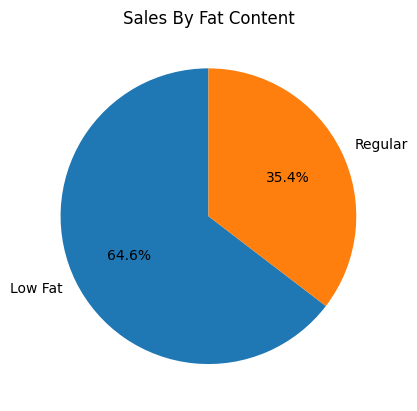

In [31]:
sales_byFat=df.groupby("Item Fat Content")["Sales"].sum()
plt.pie(sales_byFat,labels=sales_byFat.index,autopct='%.1f%%',startangle=90)
plt.title("Sales By Fat Content")
plt.show()

Total Sales By Item Type

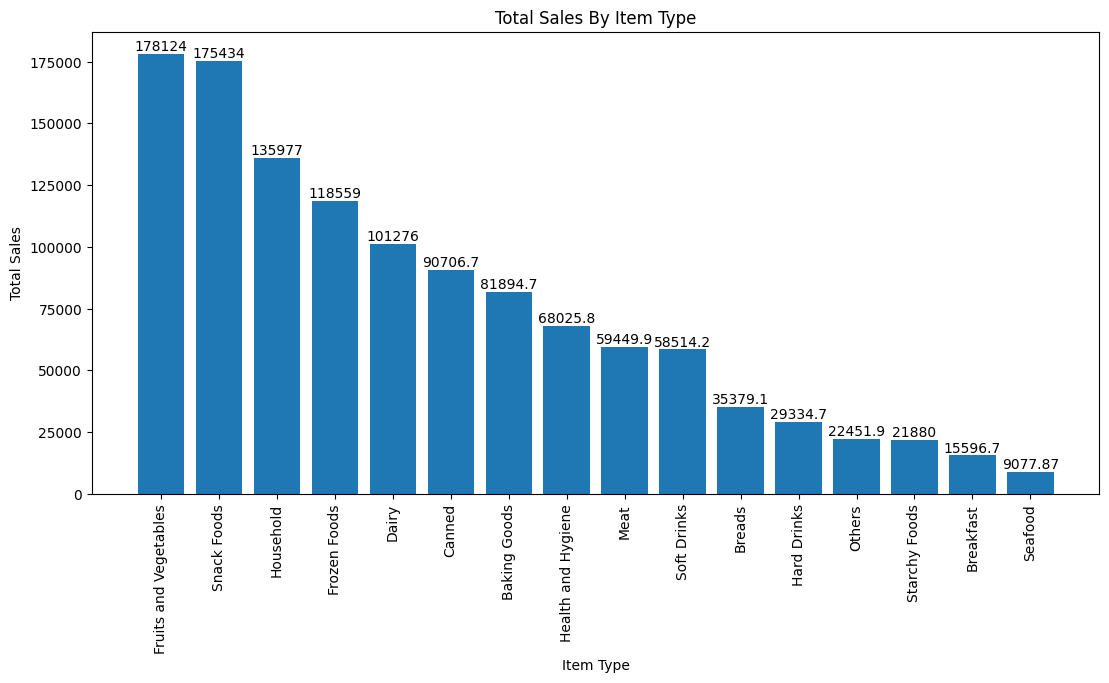

In [32]:
sales_byType=df.groupby("Item Type")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(13,6))
bars=plt.bar(sales_byType.index,sales_byType.values)
plt.bar_label(bars)


plt.xticks(rotation=90)
plt.xlabel("Item Type")
plt.ylabel("Total Sales")
plt.title("Total Sales By Item Type")
plt.show()

Fat Content By Outlet For Total Sales

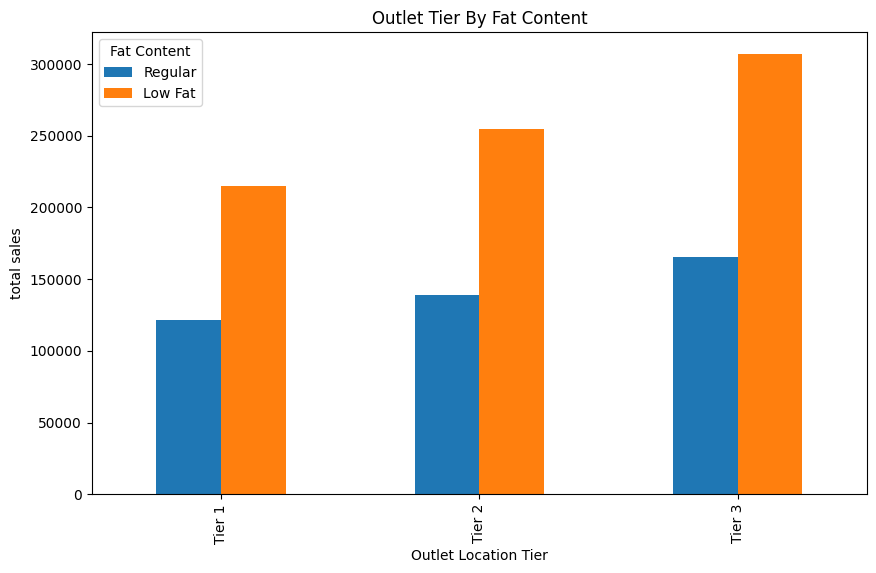

In [33]:
group=df.groupby(["Outlet Location Type","Item Fat Content"])["Sales"].sum().unstack()
group=group[["Regular","Low Fat"]]

ax=group.plot(kind='bar',figsize=(10,6),title="Outlet Tier By Fat Content")
plt.xlabel("Outlet Location Tier")
plt.ylabel("total sales")
plt.legend(title="Fat Content")
plt.show()

total sales by outlet establishment

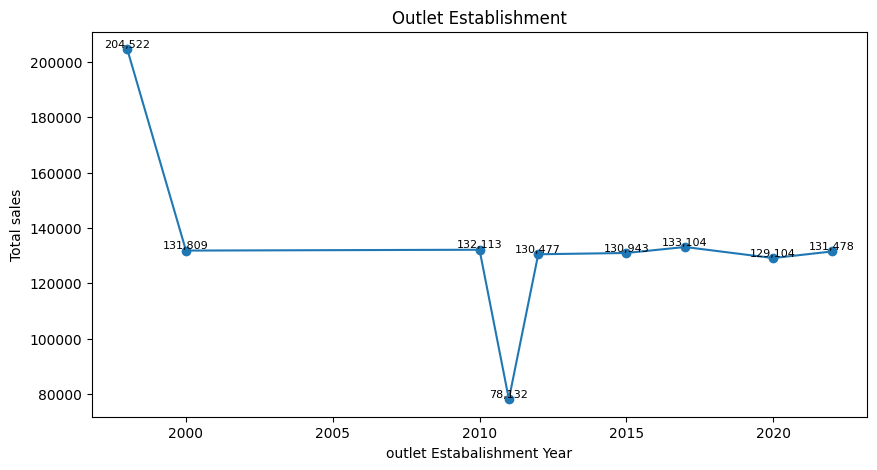

In [34]:
sales_ByYear=df.groupby("Outlet Establishment Year")["Sales"].sum().sort_index()
plt.figure(figsize=(10,5))
plt.plot(sales_ByYear.index,sales_ByYear.values,marker="o",linestyle="-")

plt.xlabel("outlet Estabalishment Year")
plt.ylabel("Total sales")
plt.title("Outlet Establishment")

for x,y in zip(sales_ByYear.index,sales_ByYear.values):
    plt.text(x,y,f'{y:,.0f}',ha="center",va="bottom",fontsize=8)
plt.show()

sales by outlet size

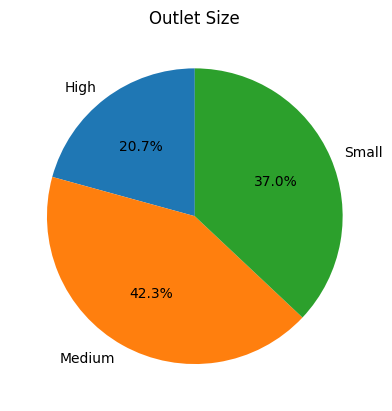

In [35]:
pie=df.groupby("Outlet Size")["Sales"].sum()
plt.pie(pie,labels=pie.index,autopct="%1.1f%%",startangle=90)
plt.title("Outlet Size")
plt.show()

Sales By Outlet Location

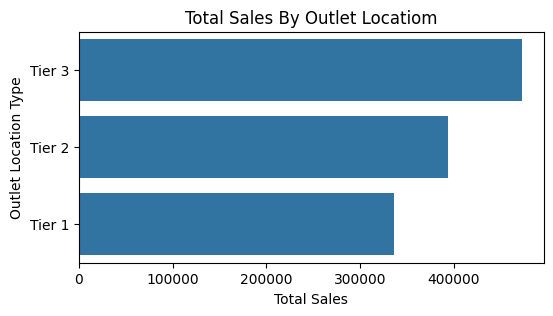

In [36]:
Sales_loc=df.groupby("Outlet Location Type")["Sales"].sum().reset_index().sort_values("Sales",ascending=False)
plt.figure(figsize=(6,3))
ax=sns.barplot(x="Sales",y="Outlet Location Type",data=Sales_loc)
plt.title("Total Sales By Outlet Locatiom")
plt.xlabel('Total Sales')
plt.ylabel('Outlet Location Type')
plt.show()